In [2]:
import os
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [5]:
def center_and_resize(image, size=45):
    height, width = image.shape
    result = np.zeros((size, size), dtype=np.uint8)
    
    if height > size or width > size:
        scale = min(size / height, size / width)
        new_height = int(height * scale)
        new_width = int(width * scale)
        image = cv2.resize(image, (new_width, new_height))
        height, width = image.shape

    y_offset = (size - height) // 2
    x_offset = (size - width) // 2
    
    result[y_offset:y_offset+height, x_offset:x_offset+width] = image
    return result

In [6]:
def prepare_image_for_model(image):
    inverted = cv2.bitwise_not(image)
    return inverted.flatten()

In [7]:
# загрузка данных
class DataLoader:
    def __init__(self, data_path):
        self.data_path = data_path
        self.symbols = self._get_symbol_list()
        self.train_data = []
        self.train_labels = []
        
    def _get_symbol_list(self):
        symbols = []
        for item in os.listdir(self.data_path):
            if os.path.isdir(os.path.join(self.data_path, item)):
                symbols.append(item)
        return symbols
    
    def load_training_data(self, train_ratio=0.8):
        for symbol in self.symbols:
            symbol_path = os.path.join(self.data_path, symbol)
            
            images = []
            for fname in os.listdir(symbol_path):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    images.append(os.path.join(symbol_path, fname))
            
            images.sort()
            train_count = int(len(images) * train_ratio)
            
            for i in range(train_count):
                img_path = images[i]
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    processed = cv2.bitwise_not(img)
                    centered = center_and_resize(processed)
                    self.train_data.append(centered.flatten())
                    self.train_labels.append(symbol)
        
        self.train_data = np.array(self.train_data)
        self.train_labels = np.array(self.train_labels)
        
        print(f"Загружено {len(self.train_labels)} обучающих изображений")
        print(f"Количество классов: {len(self.symbols)}")
        
        return self.train_data, self.train_labels

In [10]:
# генератор последовательностей
class SequenceGenerator:
    def __init__(self, data_path):
        self.data_path = data_path
        self.symbol_images = {}
        self._load_symbol_images()
    
    def _load_symbol_images(self):
        for symbol in os.listdir(self.data_path):
            symbol_dir = os.path.join(self.data_path, symbol)
            if os.path.isdir(symbol_dir):
                images = []
                for fname in os.listdir(symbol_dir):
                    if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(symbol_dir, fname)
                        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                        if img is not None:
                            images.append(img)
                
                if images:
                    self.symbol_images[symbol] = images
                    print(f"Загружено {len(images)} изображений для символа '{symbol}'")
    
    def create_sequence(self, length=8):
        if not self.symbol_images:
            print("Нет доступных символов")
            return None
        
        symbols = list(self.symbol_images.keys())
        selected_images = []
        selected_labels = []
        
        # выбор случайных символов
        for _ in range(length):
            symbol = random.choice(symbols)
            img = random.choice(self.symbol_images[symbol])
            selected_images.append(img)
            selected_labels.append(symbol)
        
        padding = 15
        total_width = sum(img.shape[1] for img in selected_images) + padding * (len(selected_images) - 1)
        max_height = max(img.shape[0] for img in selected_images)
        
        combined = np.ones((max_height, total_width), dtype=np.uint8) * 255
        
        x_pos = 0
        for img in selected_images:
            h, w = img.shape
            y_offset = (max_height - h) // 2
            combined[y_offset:y_offset+h, x_pos:x_pos+w] = img
            x_pos += w + padding
        
        return {
            'image': combined,
            'labels': selected_labels,
            'text': ''.join(selected_labels),
            'individual': selected_images
        }

In [11]:
class CharacterSegmenter:
    def extract_characters(self, sequence_image, true_labels):
        print(f"Исходная строка: {''.join(true_labels)}")
        
        processed = sequence_image.copy()
        kernel = np.ones((3, 3), np.uint8)
        processed = cv2.erode(processed, kernel, iterations=1)
        processed = cv2.bitwise_not(processed)
        
        _, binary = cv2.threshold(processed, 127, 255, cv2.THRESH_BINARY)
        
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])
        
        vis_img = cv2.cvtColor(processed, cv2.COLOR_GRAY2BGR)
        bounding_boxes = []
        
        for contour in contours:
            x, y, w, h = cv2.boundingRect(contour)
            if w * h > 30:
                cv2.rectangle(vis_img, (x, y), (x + w, y + h), (0, 0, 255), 1)
                bounding_boxes.append((x, y, w, h))
        
        plt.figure(figsize=(10, 3))
        plt.imshow(vis_img)
        plt.title('Найденные контуры символов')
        plt.axis('off')
        plt.show()
        
        extracted_chars = []
        
        for i, (x, y, w, h) in enumerate(bounding_boxes):
            char_img = sequence_image[y:y+h, x:x+w]
            processed_char = cv2.bitwise_not(char_img)
            centered_char = center_and_resize(processed_char)
            
            true_label = true_labels[i] if i < len(true_labels) else "?"
            extracted_chars.append((true_label, centered_char))
            
            print(f"Символ {i+1}: '{true_label}'")
        
        return extracted_chars

In [12]:
class SymbolClassifier:
    def __init__(self, k_values=[1, 3, 5, 7]):
        self.k_values = k_values
        self.models = {}
    
    def train(self, X_train, y_train):
        for k in self.k_values:
            model_name = f'KNN (k={k})'
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_train, y_train)
            self.models[model_name] = knn
            print(f"Обучена модель: {model_name}")
    
    def predict_character(self, character_image):
        features = character_image.flatten().reshape(1, -1)
        results = {}
        
        for model_name, model in self.models.items():
            prediction = model.predict(features)[0]
            results[model_name] = prediction
        
        return results
    
    def evaluate_sequence(self, character_data):
        results = {}
        
        for model_name, model in self.models.items():
            predictions = []
            
            for true_label, char_img in character_data:
                features = char_img.flatten().reshape(1, -1)
                prediction = model.predict(features)[0]
                predictions.append(prediction)
            
            correct = 0
            comparison_details = []
            
            for i, (true_label, _) in enumerate(character_data):
                if i < len(predictions) and predictions[i] == true_label:
                    correct += 1
                    comparison_details.append(f"+ Символ {i+1}: '{true_label}' --> '{predictions[i]}'")
                else:
                    comparison_details.append(f"- Символ {i+1}: '{true_label}' --> '{predictions[i]}'")
            
            accuracy = correct / len(character_data)
            
            original_text = ''.join([c[0] for c in character_data])
            predicted_text = ''.join(predictions)
            
            results[model_name] = {
                'accuracy': accuracy,
                'predictions': predictions,
                'predicted_text': predicted_text,
                'original_text': original_text,
                'correct': correct,
                'total': len(character_data),
                'details': comparison_details
            }
        
        return results

In [3]:
DATA_DIR = './data'

if not os.path.exists(DATA_DIR):
    print(f"Ошибка: директория '{DATA_DIR}' не найдена")

In [8]:
print("\n1. Загрузка данных")
data_loader = DataLoader(DATA_DIR)
X_train, y_train = data_loader.load_training_data(train_ratio=0.8)

if len(X_train) == 0:
    print("Ошибка: нет данных для обучения")


1. Загрузка данных
Загружено 180225 обучающих изображений
Количество классов: 21


In [13]:
print("\n2. Обучение классификаторов")
classifier = SymbolClassifier(k_values=[1, 3, 5, 7])
classifier.train(X_train, y_train)


2. Обучение классификаторов
Обучена модель: KNN (k=1)
Обучена модель: KNN (k=3)
Обучена модель: KNN (k=5)
Обучена модель: KNN (k=7)



3. Генерация тестовой последовательности
Загружено 14294 изображений для символа '('
Загружено 14355 изображений для символа ')'
Загружено 25112 изображений для символа '+'
Загружено 1906 изображений для символа ','
Загружено 33997 изображений для символа '-'
Загружено 6914 изображений для символа '0'
Загружено 26520 изображений для символа '1'
Загружено 26141 изображений для символа '2'
Загружено 10909 изображений для символа '3'
Загружено 7396 изображений для символа '4'
Загружено 3545 изображений для символа '5'
Загружено 3118 изображений для символа '6'
Загружено 2909 изображений для символа '7'
Загружено 3068 изображений для символа '8'
Загружено 628 изображений для символа '9'
Загружено 1464 изображений для символа 'h'
Загружено 3274 изображений для символа 't'
Загружено 3251 изображений для символа 'times'
Загружено 556 изображений для символа 'w'
Загружено 26594 изображений для символа 'X'
Загружено 9340 изображений для символа 'y'


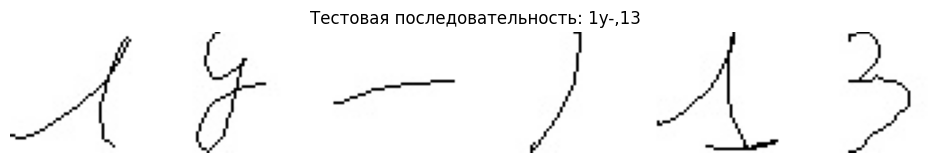

In [14]:
print("\n3. Генерация тестовой последовательности")
generator = SequenceGenerator(DATA_DIR)
test_sequence = generator.create_sequence(length=6)
if test_sequence is None:
    print("Не удалось создать тестовую последовательность")
plt.figure(figsize=(12, 3))
plt.imshow(test_sequence['image'], cmap='gray')
plt.title(f'Тестовая последовательность: {test_sequence["text"]}')
plt.axis('off')
plt.show()

Исходная строка: 1y-,13


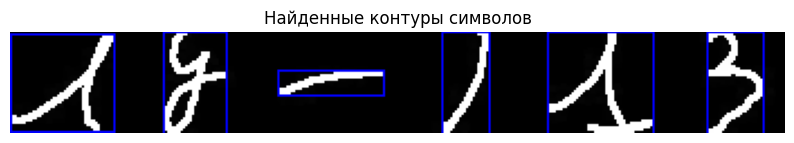

Символ 1: '1'
Символ 2: 'y'
Символ 3: '-'
Символ 4: ','
Символ 5: '1'
Символ 6: '3'


In [15]:
# сегментация символов
segmenter = CharacterSegmenter()
characters = segmenter.extract_characters(test_sequence['image'], test_sequence['labels'])

if not characters:
    print("Не удалось извлечь символы")

In [16]:
# распознавание символов
results = classifier.evaluate_sequence(characters)

# максимальная точность
max_accuracy = max(result['accuracy'] for result in results.values())

best_models = []

for model_name, result in results.items():
    print(f"\n{model_name}:")
    print(f"  Оригинал:    {result['original_text']}")
    print(f"  Распознано:  {result['predicted_text']}")
    print(f"  Точность:    {result['accuracy']:.1%} ({result['correct']}/{result['total']})")
    
    for detail in result['details']:
        print(f"    {detail}")
    
    if abs(result['accuracy'] - max_accuracy) < 0.001:
        best_models.append(model_name)


KNN (k=1):
  Оригинал:    1y-,13
  Распознано:  1y-,13
  Точность:    100.0% (6/6)
    + Символ 1: '1' --> '1'
    + Символ 2: 'y' --> 'y'
    + Символ 3: '-' --> '-'
    + Символ 4: ',' --> ','
    + Символ 5: '1' --> '1'
    + Символ 6: '3' --> '3'

KNN (k=3):
  Оригинал:    1y-,13
  Распознано:  1y-,13
  Точность:    100.0% (6/6)
    + Символ 1: '1' --> '1'
    + Символ 2: 'y' --> 'y'
    + Символ 3: '-' --> '-'
    + Символ 4: ',' --> ','
    + Символ 5: '1' --> '1'
    + Символ 6: '3' --> '3'

KNN (k=5):
  Оригинал:    1y-,13
  Распознано:  1y-,13
  Точность:    100.0% (6/6)
    + Символ 1: '1' --> '1'
    + Символ 2: 'y' --> 'y'
    + Символ 3: '-' --> '-'
    + Символ 4: ',' --> ','
    + Символ 5: '1' --> '1'
    + Символ 6: '3' --> '3'

KNN (k=7):
  Оригинал:    1y-,13
  Распознано:  ,1-)13
  Точность:    50.0% (3/6)
    - Символ 1: '1' --> ','
    - Символ 2: 'y' --> '1'
    + Символ 3: '-' --> '-'
    - Символ 4: ',' --> ')'
    + Символ 5: '1' --> '1'
    + Символ 6: '3' -

In [18]:
# подведене итогов
sorted_results = sorted(results.items(), 
                        key=lambda x: x[1]['accuracy'], 
                        reverse=True)

for model_name, result in sorted_results:
    is_best = model_name in best_models
    symbol = "+" if is_best else " "
    print(f"{symbol} {model_name}: {result['accuracy']:.1%} - '{result['predicted_text']}'")


if len(best_models) == 1:
    print(f"Лучшая модель: {best_models[0]} точность {max_accuracy:.1%}")
else:
    k_values = []
    for model_name in best_models:
        k = model_name.replace("KNN (k=", "").replace(")", "")
        k_values.append(k)
    
    print(f"Лучшие модели: {', '.join(best_models)} точность {max_accuracy:.1%}")
    print(f"Оптимальные значения k: {', '.join(k_values)}")

+ KNN (k=1): 100.0% - '1y-,13'
+ KNN (k=3): 100.0% - '1y-,13'
+ KNN (k=5): 100.0% - '1y-,13'
  KNN (k=7): 50.0% - ',1-)13'
Лучшие модели: KNN (k=1), KNN (k=3), KNN (k=5) точность 100.0%
Оптимальные значения k: 1, 3, 5
